Notebook for exploration of various ML methods of granule segmentation

In [137]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn import preprocessing
from funclib import *

# Get data
path = "Data/DKIST_example.fits"
data = fits.open(path)[0].data

# Cut to smaller data
data = data[100:300, 100:300]

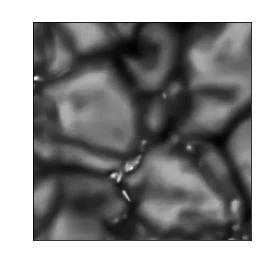

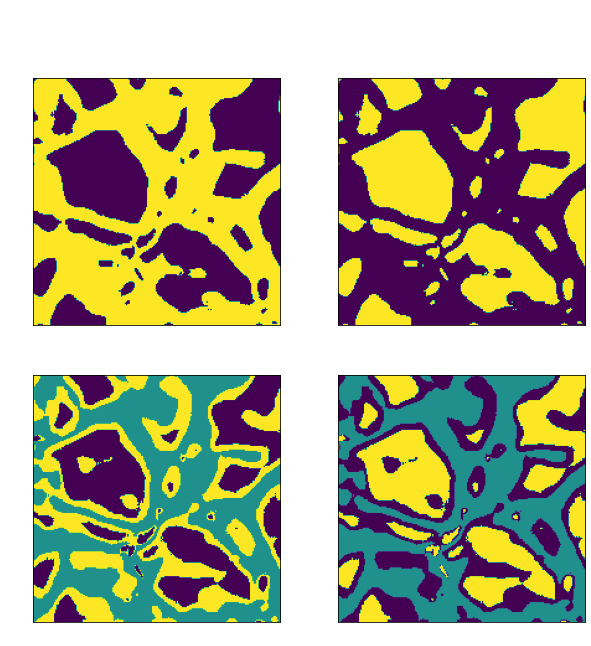

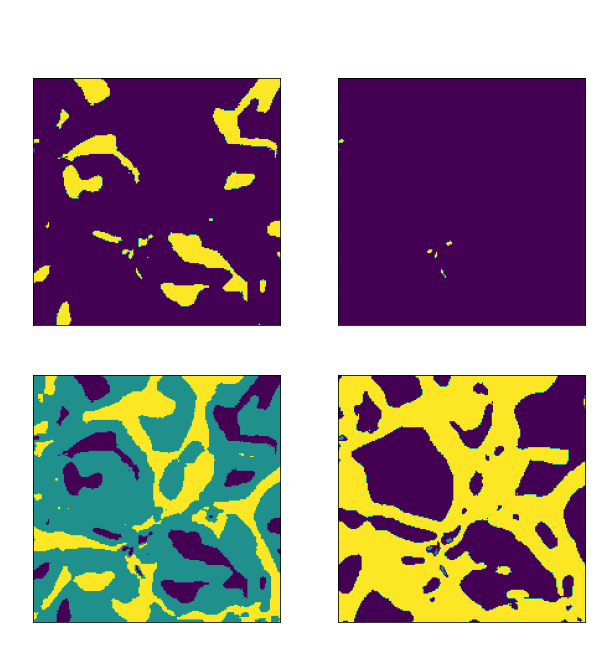

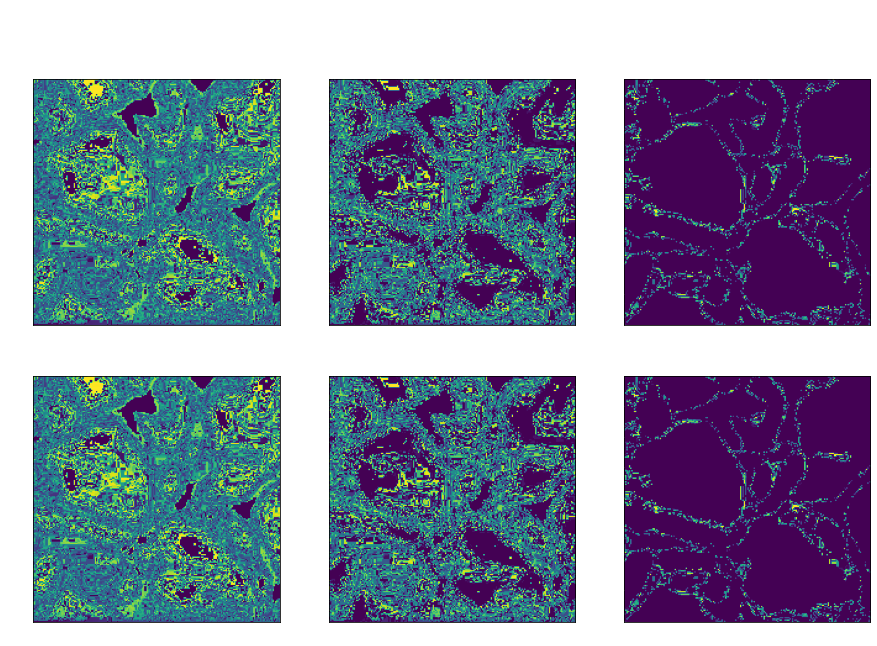

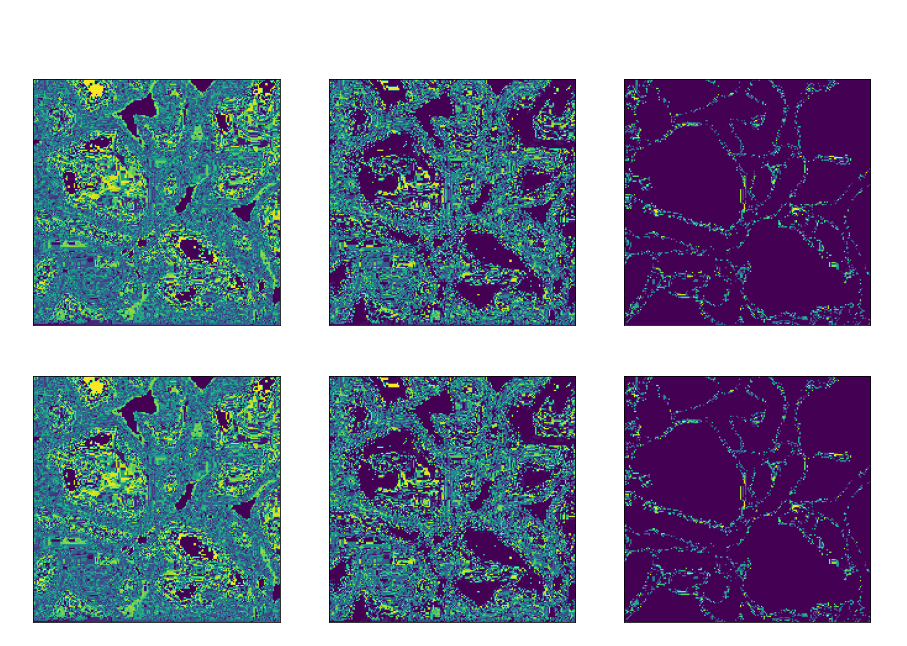

In [97]:
'''
IMPLEMENT CANNED SCI-KIT ALGORITHMS
These are all unsupervised methods
see https://scikit-learn.org/stable/modules/clustering.html

Pick algorithms that are scalable to large n
These algorithms take
    data -> (n_samples, n_features) 
Features
    Pixel value 
    Other features, for example derived from sklearn.feature_extraction (not yet attempted)
'''

# Plot data for comparison
plt.figure()
plt.imshow(data, cmap='gray', origin='lower')
plt.title('Initial data', color='white')
plt.tick_params(labelcolor='white', color='white')

# Prep data
x_size = np.shape(data)[0]
y_size = np.shape(data)[1]
data_flat = np.reshape(data, (x_size * y_size, 1))

# 1) KMeans ############################################################################
#
#       Unsupervised algorithm
#       Clusters by separating into n groups of equal variance, minimizing within-cluster sum-of-squares
#       Overall, this seems to overestimate IGM
#       3 clusters goes off the rails, does not ID brightpoints

from sklearn.cluster import KMeans

n_clusterss = [2, 3]
inits = ['k-means++', 'random'] # can also try passing locs of centers if use another alg to determine

dict = {}
i = 0
for n_clusters in n_clusterss:
    for init in inits:
        labels_flat = KMeans(n_clusters=n_clusters, init=init).fit(data_flat).labels_
        labels = np.reshape(labels_flat, (x_size, y_size))
        dict[str(i)] = [n_clusters, init, labels]
        i += 1

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('KMeans', color='white')
axs = [ax1, ax2, ax3, ax4]
for i in range(len(axs)):
    n_clusters =  dict[str(i)][0]
    init = dict[str(i)][1]
    labels = dict[str(i)][2]
    axs[i].imshow(labels, origin='lower')
    axs[i].set_title('n_clusters='+str(n_clusters)+', init='+str(init), color='white')

for ax in axs:
    ax.tick_params(labelcolor='white', color='white')


# 2) AgglomorativeCluster ################################################################
#
#       Unsupervised algorithm
#       Build nested clusters by merging and splitting them successively
#       Does best with 3 clusters and 'complete' linkage, but 3rd clsuter becomes rings around granules, not brightpoints

from sklearn.cluster import AgglomerativeClustering

n_clusterss = [2, 3]
metrics = ['euclidean'] #  'l1', 'manhattan' seem to do similarly (at least with n_clusters=2) 
linkages = ['complete', 'average'] # 'average' does terrible

dict = {}
i = 0
for n_clusters in n_clusterss:
    for metric in metrics:
        for linkage in linkages:
            labels_flat = AgglomerativeClustering(n_clusters=n_clusters, affinity=metric, linkage=linkage).fit(data_flat).labels_
            labels = np.reshape(labels_flat, (x_size, y_size))
            dict[str(i)] = [n_clusters, metric, linkage, labels]
            i += 1

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 10)) # fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('AgglomerativeClustering', color='white')
axs = [ax1, ax2, ax3, ax4] # [ax1, ax2, ax3, ax4, ax5, ax6]
for i in range(len(axs)):
    n_clusters =  dict[str(i)][0]
    metric = dict[str(i)][1]
    linkage = dict[str(i)][2]
    labels = dict[str(i)][3]
    axs[i].imshow(labels, origin='lower')
    axs[i].set_title('n_clusts='+str(n_clusters)+', metric='+str(metric)+', linkage='+str(linkage), color='white')

for ax in axs:
    ax.tick_params(labelcolor='white', color='white')



# 3) DBSCAN ############################################################################
#
#       Unsupervised algorithm
#       Clusters by identifying areas of high density separated by areas of low density 
#       MUCH faster than OPTICS, but same very poor results -  tons of tiny little pixel groups

from sklearn.cluster import DBSCAN

epss = [0.2, 0.8]
min_sampless = [50, 100, 200]
metric = 'euclidean'
algorithm = 'auto'

dict = {}
i = 0
for eps in epss:
    for min_samples in min_sampless:
        labels_flat = DBSCAN(eps=eps, min_samples=min_samples, metric=metric, algorithm=algorithm, n_jobs=3).fit(data_flat).labels_
        labels = np.reshape(labels_flat, (x_size, y_size))
        dict[str(i)] = [eps, min_samples, labels]
        i += 1

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('DBSCAN', color='white')
axs = [ax1, ax2, ax3, ax4, ax5, ax6]
for i in range(len(axs)):
    eps =  dict[str(i)][0]
    min_samples = dict[str(i)][1]
    labels = dict[str(i)][2]
    axs[i].imshow(labels, origin='lower')
    axs[i].set_title('eps='+str(eps)+', min_samps='+str(min_samples), color='white')

for ax in axs:
    ax.tick_params(labelcolor='white', color='white')


# 3) OPTICS ############################################################################
#
#       Unsupervised algorithm
#       Works simlarly to DBSCAN
#       Performs similarly to DBSCAN but takes longer

from sklearn.cluster import OPTICS

max_epss = [0.5] # doesn't seem to have much effect 
min_sampless = [4, 10] # doesn't seem to have much effect 
metric = 'euclidean'
algorithm = 'auto'
min_cluster_sizes = [50, 100, 200] 
dict = {}
i = 0
for eps in max_epss:
    for min_samples in min_sampless:
        for min_cluster_size in min_cluster_sizes:
            labels_flat = OPTICS(max_eps=eps, min_samples=min_samples, min_cluster_size=min_cluster_size, metric=metric, algorithm=algorithm).fit(data_flat).labels_
            labels = np.reshape(labels_flat, (x_size, y_size))
            dict[str(i)] = [eps, min_samples, min_cluster_size, labels]
            i += 1

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('OPTICS', color='white')
axs = [ax1, ax2, ax3, ax4, ax5, ax6]
for i in range(len(axs)):
    max_eps =  dict[str(i)][0]
    min_samples = dict[str(i)][1]
    min_cluster_size = dict[str(i)][2]
    labels = dict[str(i)][3]
    axs[i].imshow(labels, origin='lower')
    axs[i].set_title('max_eps='+str(max_eps)+', min_samp='+str(min_cluster_size)+', min_clustsize='+str(min_cluster_size), color='white')

for ax in axs:
    ax.tick_params(labelcolor='white', color='white')


In [138]:
'''
ATTEMPT SUPERVISED METHODS

Add other features (beyond pixel value) using filters
Note: currently using mostly default tunning parameters - could do more exploration to pick best ones
'''

# Get data
path = "Data/DKIST_example.fits"
data = fits.open(path)[0].data.byteswap().newbyteorder() # Not sure why this is big-endian to start with..

# Cut to smaller data
#data = data[100:300, 100:300]

# Flatten data
data1 =  data.reshape(-1) # flattened

# Initialize df of features
df = pd.DataFrame()
df['OG_value'] = data1

# Add values of different filters as features
num = 1
k1 = np.array([[1, 1, 1],  # blur (maybe usefull?)
               [1, 1, 1],
               [1, 1, 1]])/9
k2 = np.array([[0, -1, 0],  # sharpening (probably not usefull?)
               [-1, 5, -1],
               [0, -1, 0]])
k3 = np.array([[-1, -1, -1],  # edge detection (probably not usefull?)
               [-1, 8, -1],
               [-1, -1, -1]])
kernels = [k3]
for i in range(len(kernels)):
    kernel = kernels[i]
    filtered_img = cv2.filter2D(data, -1, kernel).reshape(-1) # filtered_img = cv2.GaussianBlur(data, (5,5), 0)#.reshape(-1)
    # fig, (ax1, ax2) = plt.subplots(1,2); ax1.imshow(data); ax2.imshow(filtered_img)
    df['kernal'+str(i)] = filtered_img

# Add label column using our non-ML id method
path = "c:\\Users\\lea\\OneDrive\\DKISTSegmentation\\DKISTSegmentation\\example_outputs\\DKIST\\segmented_data_DKIST_example.fits"
labels = fits.open(path)[0].data.reshape(-1) # flattened
df['labels'] =  labels

# Make X and Y and seperate training and test sets
X =  df.drop(labels =["labels"], axis=1)
Y = df['labels']
Y = preprocessing.LabelEncoder().fit_transform(Y) # turn floats 0, 1, to catagorical 0, 1
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=20)

# 1) RandomForestClassifier ###############################################################

# Train RF classifier on this data
model =  RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, Y_train)

# Predict on test set
predictions =  model.predict(X_test)
print('Random Forest accuracy on test set: ', metrics.accuracy_score(Y_test, predictions))

# 2) KNeighborsClassifier ###############################################################

# Train KNN classifier on this data
model =  KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, Y_train)

# Predict on test set
predictions =  model.predict(X_test)
print('KNN accuracy on test set: ', metrics.accuracy_score(Y_test, predictions))

Random Forest accuracy on test set:  0.9871458614309921
KNN accuracy on test set:  0.9882800342359166


In [ ]:
# # Add values of different Gabor filters as features
# num = 1
# kernels = []
# for theta in range(2):
#     theta = theta/4 * np.pi
#     for sigma in [1,3]:
#         for lambd in np.arange(0, np.pi, np.pi/4):
#             for gamma in [0.05, 0,5]:
#                 kernel = cv2.getGaborKernel((5, 5), sigma, theta, lambd, gamma, 0, ktype=cv2.CV_32F)
#                 kernels.append(kernel)
#                 filtered_img = cv2.filter2D(data1, cv2.CV_8UC3, kernel).reshape(-1)
#                 df['Gabor'+str(num)] = filtered_img
#                 num =  num + 1
#
# Add Canny edge detection as another feature
# edges = cv2.Canny(data).reshape(-1)
# df['Canny_edges'] = edges